# Kapitulli IV/V  Analiza e Dataset-it

Verifikon që `data_pipeline` ka bërë punën siç duhet: shpërndarja
real/fake, burimi (FF++/DFDC/Celeb-DF), split train/val/test,
dimensione/formate, imazhe të dëmtuara, mostra vizuale.

In [1]:
import json
from pathlib import Path
from collections import Counter

import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
FRAMES_DIR = PROJECT_ROOT / "data" / "frames"

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 11

## 1. Numri i imazheve për split dhe klasë

In [2]:
counts = {}
for split in ["train", "val", "test"]:
    for label in ["real", "fake"]:
        folder = FRAMES_DIR / split / label
        n = len(list(folder.glob("*.jpg"))) if folder.exists() else 0
        counts[(split, label)] = n

df_counts = pd.Series(counts).unstack()
df_counts["total"] = df_counts.sum(axis=1)
df_counts.loc["total"] = df_counts.sum()
df_counts

,fake,real,total
test,4477,4379,8856
train,20257,20140,40397
val,4280,4274,8554
total,29014,28793,57807


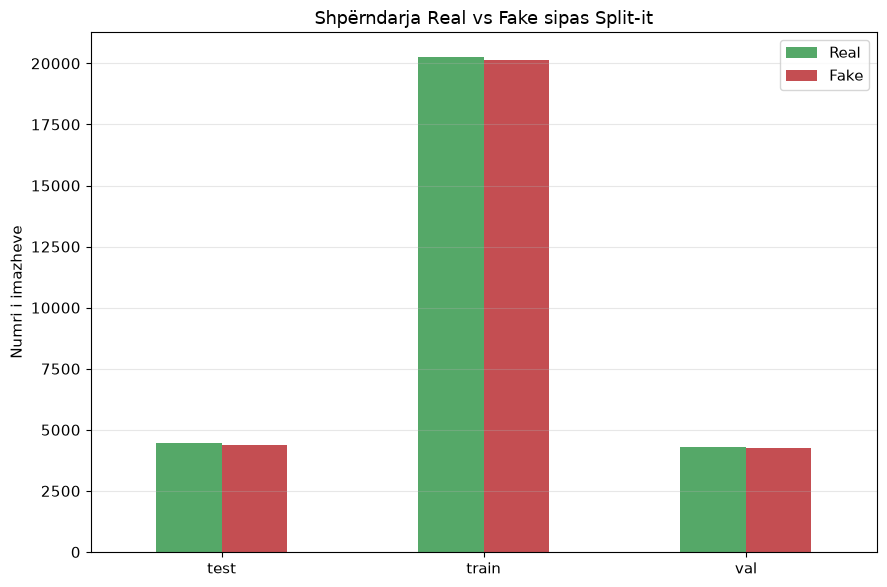

In [3]:
fig, ax = plt.subplots(figsize=(9, 6))
df_counts.drop("total").drop(columns="total").plot(kind="bar", ax=ax, color=["#55A868", "#C44E52"])
ax.set_title("Shpërndarja Real vs Fake sipas Split-it")
ax.set_ylabel("Numri i imazheve")
ax.tick_params(axis="x", rotation=0)
ax.legend(["Real", "Fake"])
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "outputs" / "dataset_split_distribution.png", dpi=150)
plt.show()

## 2. Shpërndarja sipas Dataset-it Burimor (FF++ / DFDC / Celeb-DF)

Bazuar te emri i skedarit (prefiksi `<dataset>_...`), siç e konfirmuam te struktura e `data/frames/`.

In [4]:
DATASET_PREFIXES = ["faceforensics", "dfdc", "celebdf"]

source_counts = Counter()
for split in ["train", "val", "test"]:
    for label in ["real", "fake"]:
        folder = FRAMES_DIR / split / label
        if not folder.exists():
            continue
        for f in folder.glob("*.jpg"):
            matched = next((p for p in DATASET_PREFIXES if f.name.startswith(p)), "unknown")
            source_counts[matched] += 1

df_sources = pd.Series(source_counts).sort_values(ascending=False)
df_sources

celebdf          46910
faceforensics     7152
dfdc              3745
dtype: int64

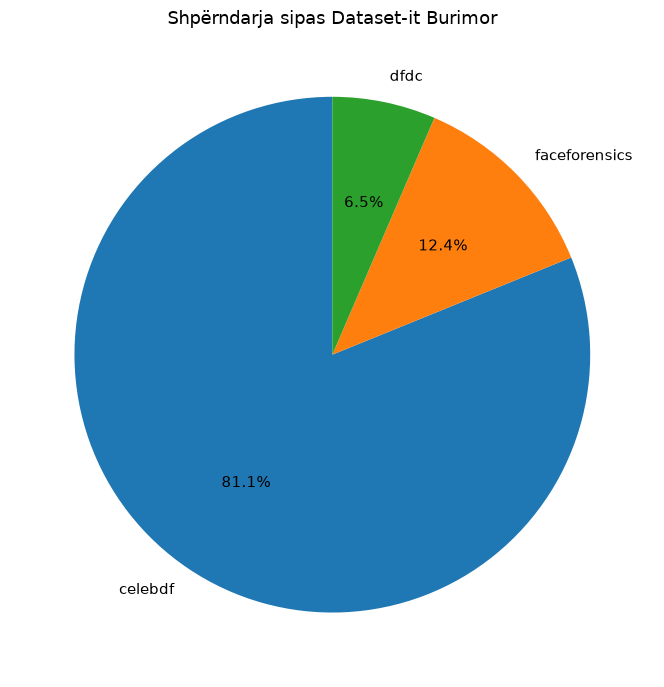

In [5]:
fig, ax = plt.subplots(figsize=(7, 7))
df_sources.plot(kind="pie", ax=ax, autopct="%1.1f%%", startangle=90)
ax.set_ylabel("")
ax.set_title("Shpërndarja sipas Dataset-it Burimor")
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "outputs" / "dataset_source_distribution.png", dpi=150)
plt.show()

## 3. Dimensionet dhe Formatet e Imazheve (mostër)

In [6]:
SAMPLE_SIZE = 200

sample_files = []
for split in ["train", "val", "test"]:
    for label in ["real", "fake"]:
        folder = FRAMES_DIR / split / label
        if folder.exists():
            sample_files.extend(list(folder.glob("*.jpg"))[:SAMPLE_SIZE // 6])

dims = []
formats = Counter()
corrupted = []

for f in sample_files:
    try:
        with Image.open(f) as img:
            dims.append(img.size)
            formats[img.format] += 1
    except Exception as e:
        corrupted.append((str(f), str(e)))

widths, heights = zip(*dims) if dims else ([], [])
print(f"Mostër e kontrolluar: {len(sample_files)} imazhe")
print(f"Dimensione unike: {set(dims)}")
print(f"Formatet: {dict(formats)}")
print(f"Imazhe të dëmtuara: {len(corrupted)}")
if corrupted:
    for path, err in corrupted[:5]:
        print(f"  - {path}: {err}")

Mostër e kontrolluar: 198 imazhe
Dimensione unike: {(224, 224)}
Formatet: {'JPEG': 198}
Imazhe të dëmtuara: 0


## 4. Mostra Vizuale (Real vs Fake)

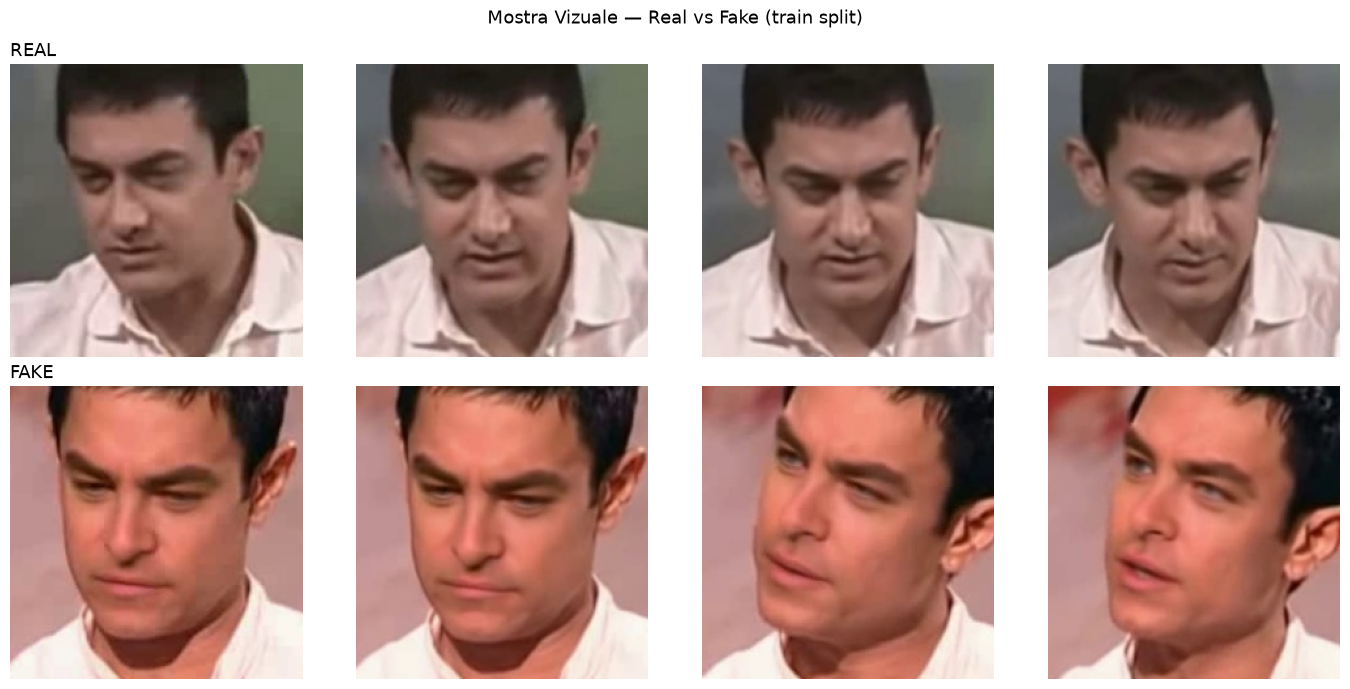

In [7]:
fig, axes = plt.subplots(2, 4, figsize=(14, 7))

for i, label in enumerate(["real", "fake"]):
    folder = FRAMES_DIR / "train" / label
    samples = list(folder.glob("*.jpg"))[:4]
    for j, img_path in enumerate(samples):
        img = Image.open(img_path)
        axes[i, j].imshow(img)
        axes[i, j].axis("off")
        if j == 0:
            axes[i, j].set_ylabel(label.upper(), fontsize=12)
    axes[i, 0].set_title(label.upper(), loc="left", fontsize=13)

plt.suptitle("Mostra Vizuale — Real vs Fake (train split)")
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "outputs" / "dataset_visual_samples.png", dpi=150)
plt.show()